# Etapa 6 - Otimização de Hiperparâmetros com Optuna

Otimiza a MLP de cada tarefa com `TPESampler` + `MedianPruner` (pruning por época).
Ao final, retreina o modelo com os melhores hiperparâmetros e o avalia uma vez no teste.

Espaço de busca: `n_layers` 1–4; `units` {32,64,128,256}; `activation` {relu,tanh,elu};
`dropout` 0–0.5; `learning_rate` log 1e-4…1e-2; `optimizer` {adam,rmsprop,sgd}(+momentum);
`batch_size` {64,128,256,512}; `l2` log 1e-6…1e-2.

Objetivo (validação): binária → maximizar ROC-AUC; multiclasse → maximizar F1 macro;
regressão → minimizar RMSE. Lógica em `src/optuna_tuning.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import pandas as pd
from IPython.display import Image

import config
from src import optuna_tuning as opt

config.set_seeds()

C:\Users\Tobias Viero\AppData\Local\Temp\ipykernel_10936\115705352.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Rodar o estudo (~25–30 min em CPU)

Execute a célula abaixo. A barra de progresso do Optuna mostra o andamento
(trial atual / total) ao vivo, e a cada tarefa são impressos o melhor valor e a
comparação no teste. Isso salva `best_params_<tarefa>.json`, as figuras `etapa6_*`
e `optuna_comparison.csv`.

> **Teste rápido** (~2–3 min) para validar o fluxo:
> `opt.run(tasks=("binary",), n_trials=5, epochs=30)`.

In [2]:
comparison = opt.run(tasks=("binary", "multiclass", "regression"), n_trials=40, epochs=100)
comparison


=== Etapa 6 — Optuna (binary) | 40 trials | objetivo: ROC-AUC (maximize) ===


  0%|          | 0/40 [00:00<?, ?it/s]

  trials concluídos=40 (podados=16) | melhor ROC-AUC (val)=0.8282


c:\Users\Tobias Viero\Desktop\Trabalho 5\src\optuna_tuning.py:137: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(study)
c:\Users\Tobias Viero\Desktop\Trabalho 5\src\optuna_tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(study)


  retreinando o modelo final com os melhores hiperparâmetros...
  TESTE -> baseline ROC-AUC=0.8262081737749918 | otimizado=0.8267

=== Etapa 6 — Optuna (multiclass) | 40 trials | objetivo: F1 macro (maximize) ===


...

  0%|          | 0/40 [00:00<?, ?it/s]

  trials concluídos=40 (podados=24) | melhor RMSE (val)=5.9222


c:\Users\Tobias Viero\Desktop\Trabalho 5\src\optuna_tuning.py:137: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_optimization_history(study)
c:\Users\Tobias Viero\Desktop\Trabalho 5\src\optuna_tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = plot_param_importances(study)


  retreinando o modelo final com os melhores hiperparâmetros...
  TESTE -> baseline RMSE=6.0244427816967905 | otimizado=6.0115

Comparação original × otimizado salva em outputs/metrics/optuna_comparison.csv
    tarefa  metrica  baseline_teste  otimizado_teste   delta  baseline_tempo_treino_s  otimizado_tempo_treino_s  n_trials  n_podados
    binary  ROC-AUC        0.826208           0.8267  0.0005                    18.09                     79.08        40         16
multiclass F1 macro        0.423522           0.4426  0.0190                    13.81                     23.71        40         15
regression     RMSE        6.024443           6.0115 -0.0130                    37.49                     70.21        40         24

Etapa 6 concluída.


,tarefa,metrica,baseline_teste,otimizado_teste,delta,baseline_tempo_treino_s,otimizado_tempo_treino_s,n_trials,n_podados
0,binary,ROC-AUC,0.826208,0.8267,0.0005,18.09,79.08,40,16
1,multiclass,F1 macro,0.423522,0.4426,0.0190,13.81,23.71,40,15
2,regression,RMSE,6.024443,6.0115,-0.0130,37.49,70.21,40,24


## 2. Melhores hiperparâmetros por tarefa

In [3]:
for task in ("binary", "multiclass", "regression"):
    bp = json.load(open(config.MODELS_DIR / f"best_params_{task}.json", encoding="utf-8"))
    print(f"\n=== {task} | objetivo: {bp['objetivo']} ({bp['direcao']}) ===")
    print(f"valor (validação): {bp['valor_validacao']:.4f} | trials: {bp['n_trials']} (podados: {bp['n_podados']})")
    print("best_params:", json.dumps(bp["best_params"], ensure_ascii=False))


=== binary | objetivo: ROC-AUC (maximize) ===
valor (validação): 0.8282 | trials: 40 (podados: 16)
best_params: {"n_layers": 1, "units_l0": 256, "optimizer": "adam", "activation": "relu", "dropout": 0.34881916564298093, "learning_rate": 0.0001341964972079628, "batch_size": 64, "l2": 1.1584359345421857e-05}

=== multiclass | objetivo: F1 macro (maximize) ===
valor (validação): 0.4427 | trials: 40 (podados: 15)
best_params: {"n_layers": 2, "units_l0": 256, "units_l1": 32, "optimizer": "adam", "activation": "elu", "dropout": 0.094002281105948, "learning_rate": 0.004234819606456936, "batch_size": 256, "l2": 0.00402343705151094}

=== regression | objetivo: RMSE (minimize) ===
valor (validação): 5.9222 | trials: 40 (podados: 24)
best_params: {"n_layers": 1, "units_l0": 256, "optimizer": "adam", "activation": "relu", "dropout": 0.11883026394846162, "learning_rate": 0.0006917271753674749, "batch_size": 64, "l2": 0.0012127785166346245}


## 3. Comparação original × otimizado (no teste)

In [4]:
pd.read_csv(config.METRICS_DIR / "optuna_comparison.csv")

,tarefa,metrica,baseline_teste,otimizado_teste,delta,baseline_tempo_treino_s,otimizado_tempo_treino_s,n_trials,n_podados
0,binary,ROC-AUC,0.826208,0.8267,0.0005,18.09,79.08,40,16
1,multiclass,F1 macro,0.423522,0.4426,0.0190,13.81,23.71,40,15
2,regression,RMSE,6.024443,6.0115,-0.0130,37.49,70.21,40,24


## 4. Histórico de otimização e importância dos hiperparâmetros (binária)

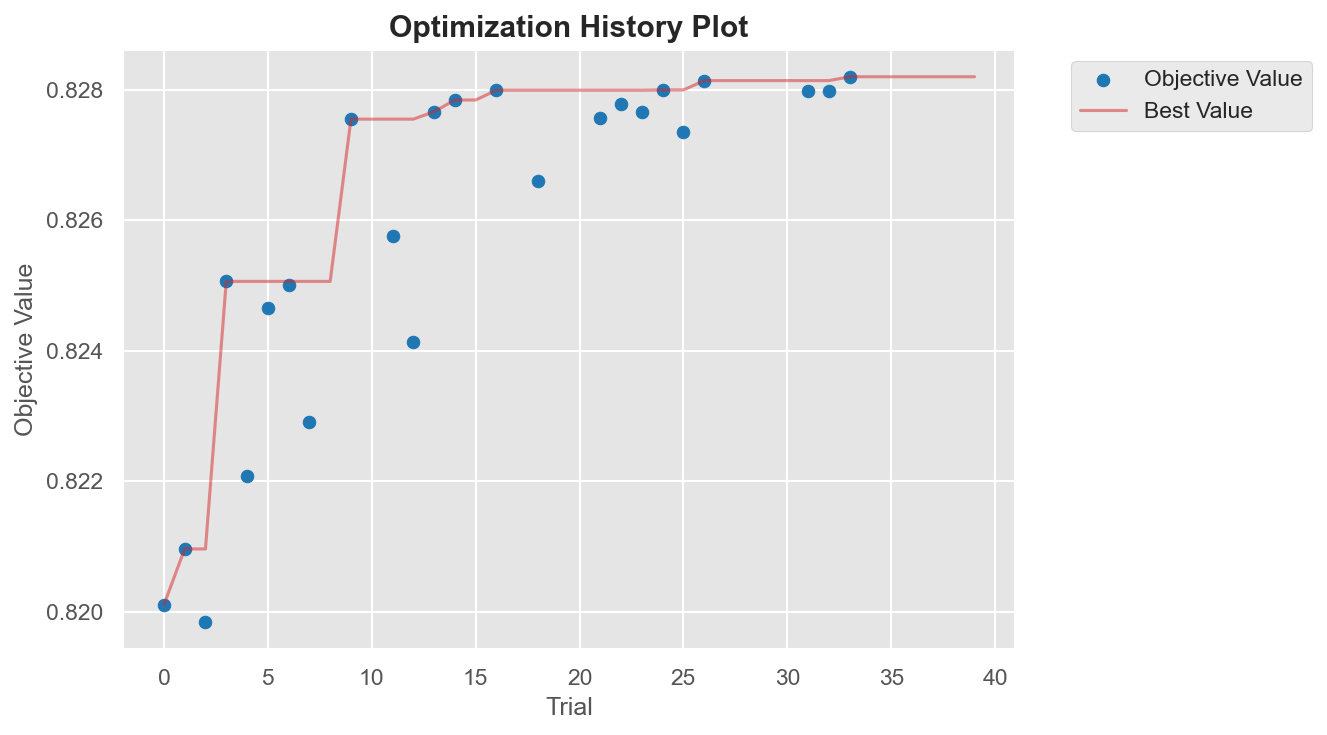

In [5]:
Image(str(config.FIGURES_DIR / "etapa6_optuna_history_binary.png"))

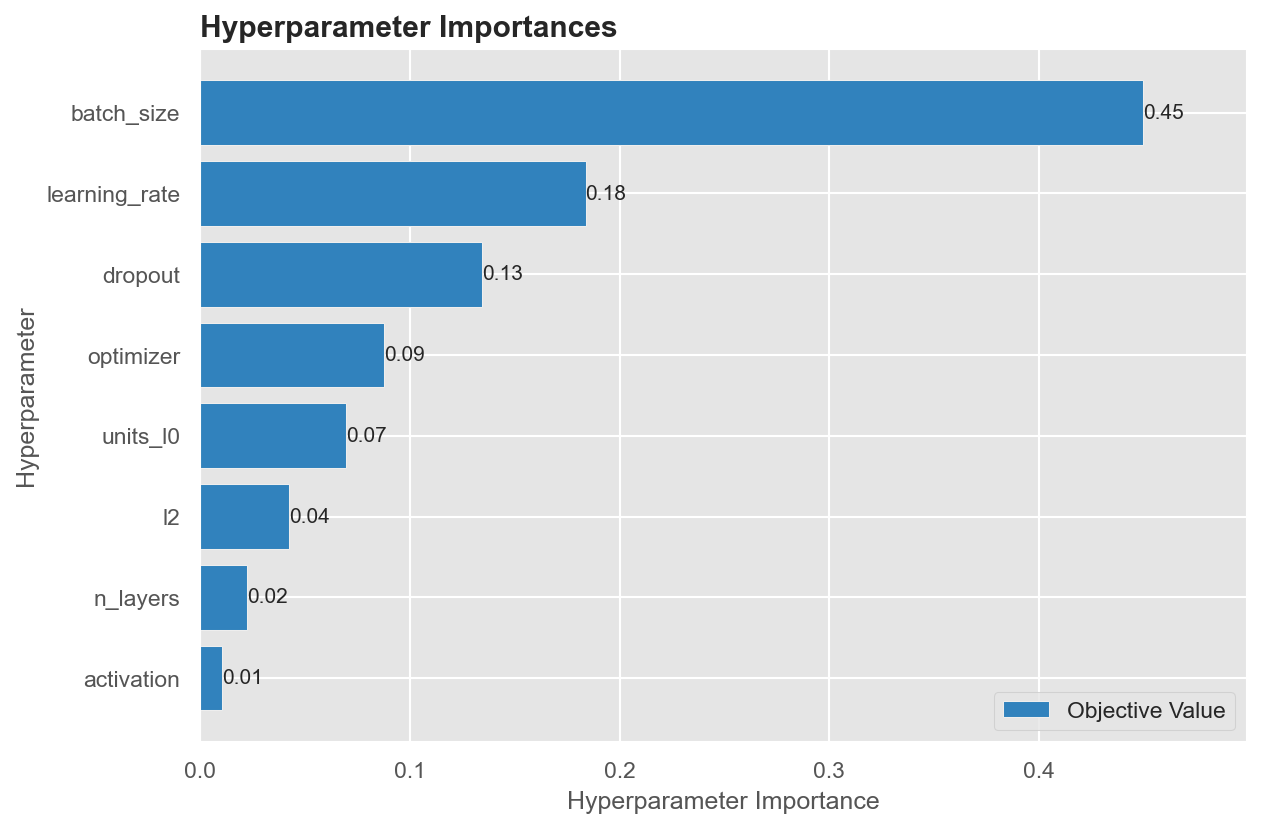

In [6]:
Image(str(config.FIGURES_DIR / "etapa6_optuna_param_importance_binary.png"))

## 5. Multiclasse e regressão - históricos

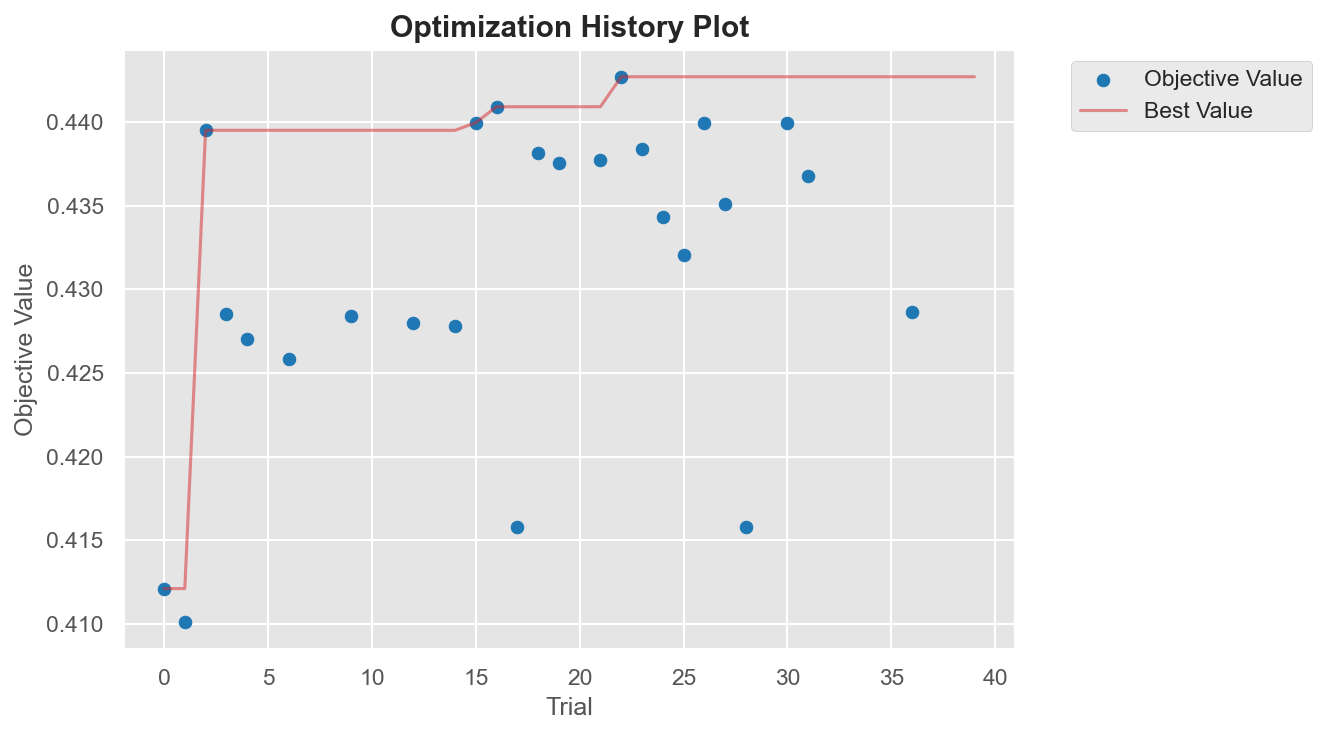

In [7]:
Image(str(config.FIGURES_DIR / "etapa6_optuna_history_multiclass.png"))

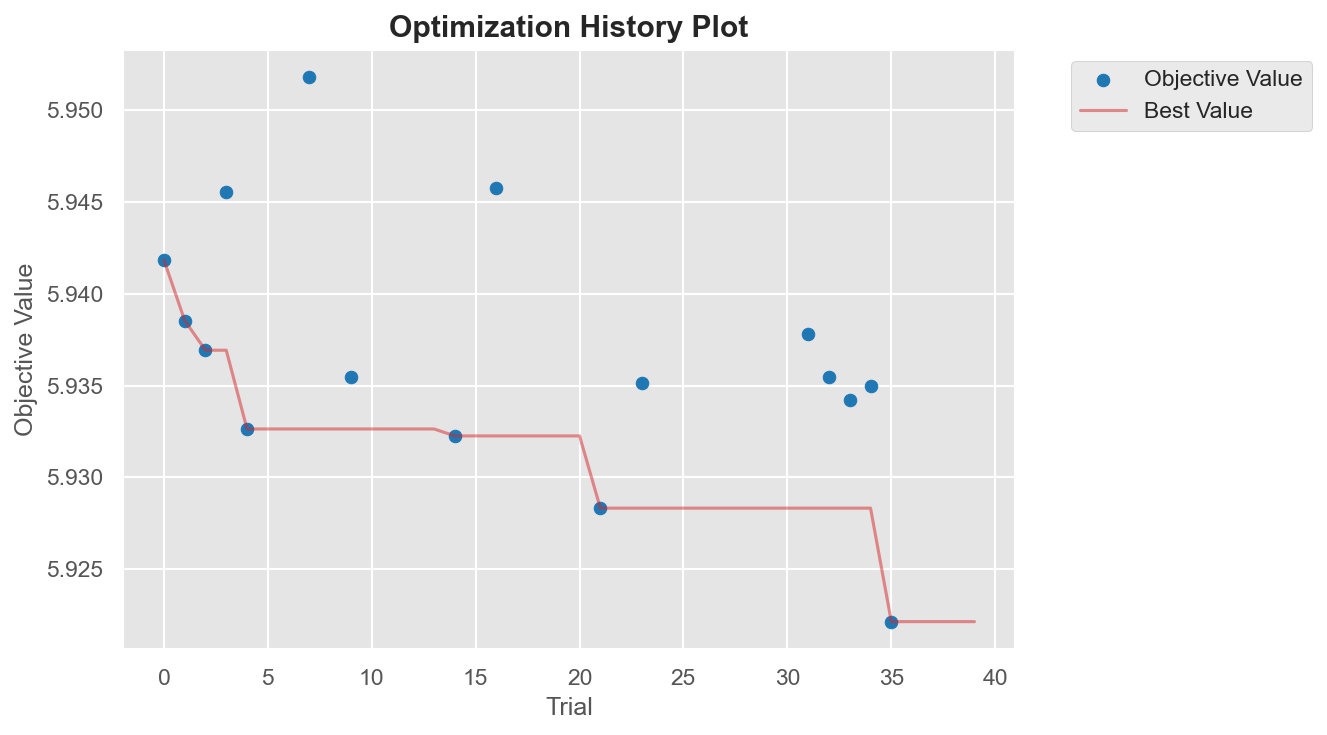

In [8]:
Image(str(config.FIGURES_DIR / "etapa6_optuna_history_regression.png"))